<a href="https://colab.research.google.com/github/piyakorn-h/Super-AI-Engineer-Season-6/blob/main/Sleep_Stage_Classification_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -o -q '/content/drive/MyDrive/super-ai-engineer-ss-6-sleep-stage-classification.zip' -d '/content/'

# หลังจากแตกไฟล์แล้ว Path จะอยู่ในเครื่อง Colab (Temporary Storage)
train_path = '/content/train/train'
test_path  = '/content/test_segment'

# ลองเช็กดูว่าไฟล์มาครบไหมหลังจาก Unzip
import os
print(f"จำนวนไฟล์ใน Train: {len(os.listdir(train_path))}")
print(f"จำนวนไฟล์ใน Test: {len(os.listdir(test_path))}")

จำนวนไฟล์ใน Train: 83
จำนวนไฟล์ใน Test: 1


In [ ]:
import pandas as pd
import numpy as np
import glob
import os

# 1. ตั้งค่า Path
train_path = '/content/train/train'
save_dir = '/content/drive/MyDrive/Sleep_Project'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

train_files = sorted(glob.glob(os.path.join(train_path, '*.csv')))
print(f"พบไฟล์ Train ทั้งหมด: {len(train_files)} ไฟล์")

def process_train_file_v3(file_path):
    cols = ['BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'TEMP', 'EDA', 'HR', 'IBI']

    try:
        df = pd.read_csv(file_path)

        # --- [NEW] ซ่อมข้อมูลก่อนหั่น Window ---
        df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

        # หาสิ่งที่น่าจะเป็นเฉลย
        possible_targets = [c for c in df.columns if 'Sleep' in c or 'Stag' in c]
        if not possible_targets: return None
        target_col = possible_targets[0]

        window_size = 16 * 30 # 480 แถว
        features_list = []

        for i in range(0, len(df), window_size):
            window = df.iloc[i : i + window_size]
            if len(window) < window_size: continue

            row = {}
            for col in cols:
                if col in window.columns:
                    s = window[col]
                    # --- [CRITICAL] สกัดให้ครบ 6 ตัวเหมือน Test V3 ---
                    row[f'{col}_mean'] = s.mean()
                    row[f'{col}_std']  = s.std()
                    row[f'{col}_max']  = s.max()
                    row[f'{col}_min']  = s.min()
                    row[f'{col}_skew'] = s.skew()
                    row[f'{col}_kurt'] = s.kurt()
                else:
                    for stat in ['mean', 'std', 'max', 'min', 'skew', 'kurt']:
                        row[f'{col}_{stat}'] = 0

            # เก็บเฉลย (ฐานนิยม)
            row['sleep_stage'] = window[target_col].mode()[0]
            features_list.append(row)

        return pd.DataFrame(features_list)
    except Exception as e:
        print(f"Error ในไฟล์ {os.path.basename(file_path)}: {e}")
        return None

# 2. เริ่มรันลูป
all_train_data = []
for f in train_files:
    print(f"กำลังย่อยไฟล์: {os.path.basename(f)}...")
    df_temp = process_train_file_v3(f)
    if df_temp is not None:
        all_train_data.append(df_temp)

# 3. รวมร่างและเซฟ
if all_train_data:
    df_train_final = pd.concat(all_train_data, ignore_index=True)
    df_train_final = df_train_final.fillna(0) # กันค่า NaN จาก Skew/Kurt

    save_path = os.path.join(save_dir, 'train_tabular_v3.csv') # เปลี่ยนชื่อเป็น v3
    df_train_final.to_csv(save_path, index=False)

    print(f"\n✅ เรียบร้อย! ไฟล์รวมร่างไปอยู่ที่: {save_path}")
    print(f"📊 ได้ข้อมูลรวมทั้งหมด: {len(df_train_final)} แถว")

พบไฟล์ Train ทั้งหมด: 83 ไฟล์
กำลังย่อยไฟล์: train001.csv...


/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


กำลังย่อยไฟล์: train002.csv...


/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


กำลังย่อยไฟล์: train003.csv...


...

กำลังย่อยไฟล์: train082.csv...


/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


กำลังย่อยไฟล์: train083.csv...


/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2823686584.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')



✅ เรียบร้อย! ไฟล์รวมร่างไปอยู่ที่: /content/drive/MyDrive/Sleep_Project/train_tabular_v3.csv
📊 ได้ข้อมูลรวมทั้งหมด: 66745 แถว


In [ ]:
import pandas as pd
import numpy as np
import glob
import os

# 1. กำหนด Path (อ้างอิงตามโครงสร้าง Hackathon)
test_root = '/content/test_segment/test_segment'
test_files = sorted(glob.glob(os.path.join(test_root, '**/*.csv'), recursive=True))

print(f"พบไฟล์ Test ทั้งหมด {len(test_files)} ไฟล์")

def process_test_file_v3(file_path):
    cols = ['BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'TEMP', 'EDA', 'HR', 'IBI']
    try:
        df = pd.read_csv(file_path)

        # --- [CRITICAL] ซ่อมข้อมูลและสกัดฟีเจอร์ให้ตรงกับ Train V3 ---
        # 1. เติมค่าว่างด้วย Linear Interpolation
        df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

        row = {}
        for col in cols:
            if col in df.columns:
                s = df[col]
                # สกัดให้ครบ 6 ตัว (ต้องมี Skew/Kurt นะน้องมึงอย่าลืม!)
                row[f'{col}_mean'] = s.mean()
                row[f'{col}_std']  = s.std()
                row[f'{col}_max']  = s.max()
                row[f'{col}_min']  = s.min()
                row[f'{col}_skew'] = s.skew()
                row[f'{col}_kurt'] = s.kurt()
            else:
                # กรณีคอลัมน์หาย ให้ใส่ 0 ไว้กันโมเดลบึ้ม
                for stat in ['mean', 'std', 'max', 'min', 'skew', 'kurt']:
                    row[f'{col}_{stat}'] = 0

        # เก็บ ID จากชื่อไฟล์ (เช่น test001_00000)
        row['id'] = os.path.splitext(os.path.basename(file_path))[0]
        return row

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# 2. เริ่มรันลูปสกัดฟีเจอร์
test_features_list = []
for i, f in enumerate(test_files):
    if i % 500 == 0: # ปรับให้โชว์ทุก 500 ไฟล์จะได้ไม่รก
        print(f"กำลังประมวลผลไฟล์ที่ {i} จาก {len(test_files)}...")

    feat = process_test_file_v3(f)
    if feat:
        test_features_list.append(feat)

# 3. รวมร่างและจัดการ NaN สุดท้าย
df_test_final = pd.DataFrame(test_features_list)
df_test_final = df_test_final.fillna(0) # กันเหนียวเผื่อ Skew คำนวณไม่ได้

# 4. เซฟลง Drive เป็น V3
save_test_path = '/content/drive/MyDrive/Sleep_Project/test_tabular_v3.csv'
os.makedirs(os.path.dirname(save_test_path), exist_ok=True)
df_test_final.to_csv(save_test_path, index=False)

print(f"--- เสร็จเรียบร้อย! ---")
print(f"ได้ข้อมูล Test V3 ทั้งหมด {len(df_test_final)} แถว พร้อมส่ง Prediction")

พบไฟล์ Test ทั้งหมด 7832 ไฟล์
กำลังประมวลผลไฟล์ที่ 0 จาก 7832...


/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(met

กำลังประมวลผลไฟล์ที่ 500 จาก 7832...


/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(met

กำลังประมวลผลไฟล์ที่ 1000 จาก 7832...


...

กำลังประมวลผลไฟล์ที่ 7000 จาก 7832...


/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(met

กำลังประมวลผลไฟล์ที่ 7500 จาก 7832...


/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_6287/2636681467.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate(method='linear').fillna(met

--- เสร็จเรียบร้อย! ---
ได้ข้อมูล Test V3 ทั้งหมด 7832 แถว พร้อมส่ง Prediction


In [ ]:
import pandas as pd

# โหลดตารางที่ทำไว้ (เช็ก Path ใน Drive ของคุณอีกทีนะครับ)
train_df = pd.read_csv('/content/drive/MyDrive/Sleep_Project/train_tabular_v3.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Sleep_Project/test_tabular_v3.csv')

print(f"ขนาดของ Train: {train_df.shape}")
print(f"ขนาดของ Test: {test_df.shape}")

# เช็กว่ามีค่า NaN (ค่าว่าง) หลุดมาไหม ถ้ามีให้เติมด้วย 0 หรือ Mean
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

ขนาดของ Train: (66745, 49)
ขนาดของ Test: (7832, 49)


--- การกระจายตัวของแต่ละ Sleep Stage ---
             Count  Percentage (%)
sleep_stage                       
N1            7753       11.615851
N2           33786       50.619522
N3            2345        3.513372
R             7033       10.537119
W            15828       23.714136


<Axes: title={'center': 'Distribution of Sleep Stages'}, xlabel='sleep_stage'>

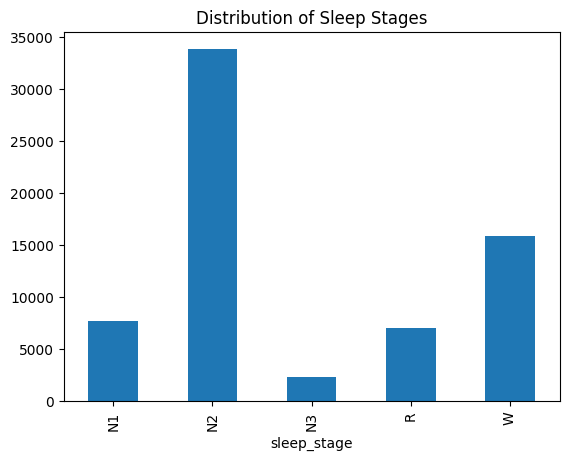

In [ ]:
# 1. ดูจำนวนข้อมูลในแต่ละ Class
class_counts = train_df['sleep_stage'].value_counts().sort_index()
class_percentage = train_df['sleep_stage'].value_counts(normalize=True).sort_index() * 100

# 2. แสดงผลแบบตารางให้ดูง่ายๆ
imbalance_check = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentage
})

print("--- การกระจายตัวของแต่ละ Sleep Stage ---")
print(imbalance_check)

# 3. ลองพลอตเป็นกราฟแท่งดูความสูงต่ำ
imbalance_check['Count'].plot(kind='bar', title='Distribution of Sleep Stages')

## Implement XGBoost

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight

# 1. เตรียมข้อมูล Train ทั้งหมด
X_train_full = train_df.drop(columns=['sleep_stage'])
y_train_full = train_df['sleep_stage']

# 2. เตรียมข้อมูล Test (เช็กว่าคอลัมน์ต้องเรียงเหมือน X_train_full เป๊ะ)
# ถ้ามีคอลัมน์ 'id' ใน Test ให้เก็บแยกไว้ก่อน
X_test_final = test_df[X_train_full.columns]

# 3. คำนวณ Class Weight (เพราะ N3 น้อยมาก ต้องเน้นเป็นพิเศษ)
classes = np.unique(y_train_full)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_full)
class_weights_dict = dict(zip(classes, weights))

# สร้าง sample_weight สำหรับข้อมูลทุกแถว
sample_weights = np.array([class_weights_dict[cls] for cls in y_train_full])

In [ ]:
from sklearn.preprocessing import LabelEncoder

# สร้างโมเดล XGBoost
model = XGBClassifier(
    n_estimators=800,           # ค่าที่ดีที่สุดจาก Grid Search
    learning_rate=0.01,         # ค่าที่ดีที่สุดจาก Grid Search
    max_depth=5,                # ค่าที่ดีที่สุดจาก Grid Search
    min_child_weight=5,         # ค่าที่ดีที่สุดจาก Grid Search
    subsample=0.8,              # ค่าที่ดีที่สุดจาก Grid Search
    objective='multi:softprob',
    tree_method='hist',
    random_state=42
)

# แปลง y_train_full จาก string เป็น numerical labels
le = LabelEncoder()
y_train_full_encoded = le.fit_transform(y_train_full)

print("เริ่มเทรนโมเดลด้วยข้อมูล 100%...")
model.fit(X_train_full, y_train_full_encoded, sample_weight=sample_weights)
print("เทรนเสร็จเรียบร้อย!")

เริ่มเทรนโมเดลด้วยข้อมูล 100%...
เทรนเสร็จเรียบร้อย!


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# ทำนายผลบนข้อมูล Train เพื่อดูประสิทธิภาพของโมเดล
y_pred_train_encoded = model.predict(X_train_full)
y_pred_train_decoded = le.inverse_transform(y_pred_train_encoded)

# แปลง y_train_full_encoded กลับเป็น label เดิมสำหรับ Report
y_train_full_decoded = le.inverse_transform(y_train_full_encoded)

print("--- Confusion Matrix on Training Data ---")
print(confusion_matrix(y_train_full_decoded, y_pred_train_decoded))

print("\n--- Classification Report on Training Data ---")
print(classification_report(y_train_full_decoded, y_pred_train_decoded))

--- Confusion Matrix on Training Data ---
[[ 4165  1181   175   940  1292]
 [ 5445 17779  3038  4743  2781]
 [   17    80  2208    21    19]
 [  492   588   130  5554   269]
 [ 2280  1658   427  1432 10031]]

--- Classification Report on Training Data ---
              precision    recall  f1-score   support

          N1       0.34      0.54      0.41      7753
          N2       0.84      0.53      0.65     33786
          N3       0.37      0.94      0.53      2345
           R       0.44      0.79      0.56      7033
           W       0.70      0.63      0.66     15828

    accuracy                           0.60     66745
   macro avg       0.54      0.69      0.56     66745
weighted avg       0.69      0.60      0.61     66745



In [ ]:
# ทายผลจากไฟล์ Test
y_pred_test = model.predict(X_test_final)

# แปลงค่าทำนายจากตัวเลขกลับเป็น Sleep Stage ที่เป็นตัวอักษร
y_pred_test_decoded = le.inverse_transform(y_pred_test)

# สร้างตาราง Submission (ปรับชื่อคอลัมน์ตามโจทย์ Kaggle นะครับ)
submission = pd.DataFrame({
    'id': test_df['id'],         # ใช้ ID จากไฟล์ Test ที่เราเก็บไว้
    'lables': y_pred_test_decoded # คำทำนายที่แปลงกลับเป็นชื่อ Sleep Stage แล้ว
})

# เซฟไฟล์ส่งคำตอบเข้า Drive
submission.to_csv('/content/drive/MyDrive/Sleep_Project/submission_v4.csv', index=False)
print("สร้างไฟล์ Submission สำเร็จ! อยู่ใน Drive แล้วครับ")

สร้างไฟล์ Submission สำเร็จ! อยู่ใน Drive แล้วครับ


--- การกระจายตัวของ Sleep Stage ที่โมเดลทำนายบนข้อมูล Test ---
lables
N1    1350
N2    2931
N3     720
R      848
W     1983
Name: count, dtype: int64


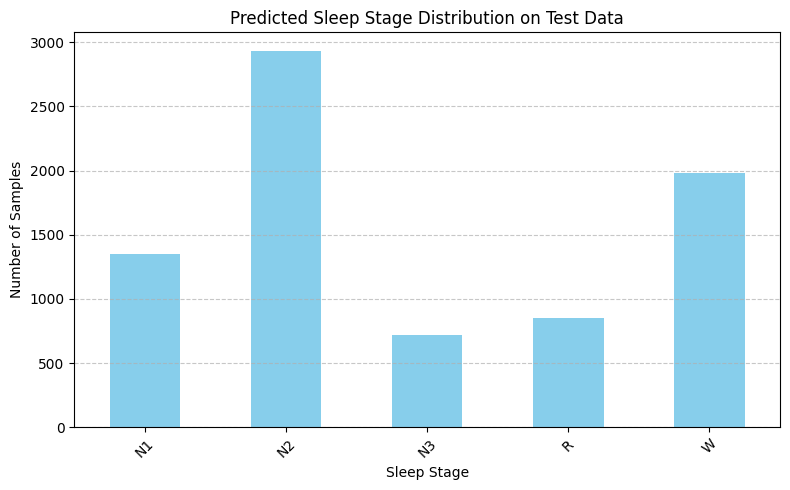

In [ ]:
import matplotlib.pyplot as plt

# นับจำนวนแต่ละ class ที่ทำนายได้บนข้อมูล Test
predicted_class_counts = submission['lables'].value_counts().sort_index()

print("--- การกระจายตัวของ Sleep Stage ที่โมเดลทำนายบนข้อมูล Test ---")
print(predicted_class_counts)

# พลอตกราฟแท่งแสดงการกระจายตัว
plt.figure(figsize=(8, 5))
predicted_class_counts.plot(kind='bar', title='Predicted Sleep Stage Distribution on Test Data', color='skyblue')
plt.xlabel('Sleep Stage')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## XGBoost with Skew & Kurtosis

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

# --- 1. ฟังก์ชันสกัดฟีเจอร์ V3 (ล็อกเป้า Sleep Stage) ---
def process_file_v3(file_path, is_train=True):
    cols = ['BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'TEMP', 'EDA', 'HR', 'IBI']
    try:
        df = pd.read_csv(file_path)

        # ซ่อมข้อมูลที่แหว่ง (Missing Values) ก่อนหั่น Window
        df = df.interpolate(method='linear')
        df = df.fillna(method='ffill').fillna(method='bfill')

    except Exception as e:
        print(f"❌ Error reading {file_path}: {e}")
        return pd.DataFrame()

    target_col = 'sleep_stage'
    # หมายเหตุ: ถ้าในไฟล์จริงสะกดต่างจากนี้ (เช่น Sleep_Stage)
    # โค้ดด้านล่างจะช่วยเช็คชื่อที่ใกล้เคียงให้ครับ
    if is_train and target_col not in df.columns:
        possible = [c for c in df.columns if 'sleep' in c.lower() or 'stage' in c.lower()]
        if possible: target_col = possible[0]

    window_size = 480 # 16Hz * 30s
    features = []

    for i in range(0, len(df), window_size):
        window = df.iloc[i : i + window_size]
        if len(window) < window_size:
            continue

        row = {}
        for col in cols:
            if col in window.columns:
                s = window[col]
                # สกัด 6 ฟีเจอร์ (เน้น Skew/Kurt เพื่อแยก Stage)
                row[f'{col}_mean'] = s.mean()
                row[f'{col}_std']  = s.std()
                row[f'{col}_max']  = s.max()
                row[f'{col}_min']  = s.min()
                row[f'{col}_skew'] = s.skew()
                row[f'{col}_kurt'] = s.kurt()
            else:
                for stat in ['mean', 'std', 'max', 'min', 'skew', 'kurt']:
                    row[f'{col}_{stat}'] = 0

        if is_train:
            # ดึงเฉลยจากวินโดว์นั้น (เอาค่าที่พบบ่อยที่สุด)
            row['sleep_stage'] = window[target_col].mode()[0]
        else:
            # สร้าง ID สำหรับส่ง Kaggle
            base_name = os.path.splitext(os.path.basename(file_path))[0]
            row['id'] = f"{base_name}_{i//window_size}"

        features.append(row)

    return pd.DataFrame(features)

In [ ]:
# --- 2. สั่งรันประมวลผลทั้งหมด ---
train_path = '/content/train/train'
test_root = '/content/test_segment/test_segment'
save_dir = '/content/drive/MyDrive/Sleep_Project'

# รันฝั่ง Train
print("🚀 กำลังปั้นข้อมูล Train V3...")
train_files = sorted(glob.glob(os.path.join(train_path, '*.csv')))
df_train_final = pd.concat([process_file_v3(f, is_train=True) for f in train_files], ignore_index=True)
df_train_final = df_train_final.fillna(0)
df_train_final.to_csv(os.path.join(save_dir, 'train_tabular_v3.csv'), index=False)

# รันฝั่ง Test
print("🚀 กำลังปั้นข้อมูล Test V3...")
test_files = sorted(glob.glob(os.path.join(test_root, '**/*.csv'), recursive=True))
df_test_final = pd.concat([process_file_v3(f, is_train=False) for f in test_files], ignore_index=True)
df_test_final = df_test_final.fillna(0)
df_test_final.to_csv(os.path.join(save_dir, 'test_tabular_v3.csv'), index=False)

print(f"\n✅ ภารกิจสำเร็จ! ข้อมูลพร้อมรบที่: {save_dir}")

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# 1. โหลดและเตรียมข้อมูล
train_df = pd.read_csv(os.path.join(save_dir, 'train_tabular_v3.csv')).fillna(0)
le = LabelEncoder()
y_encoded = le.fit_transform(train_df['sleep_stage'])
X = train_df.drop(columns=['sleep_stage'])

# 2. คำนวณน้ำหนักคลาส (Balanced)
weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights = dict(zip(np.unique(y_encoded), weights))
sample_weights = np.array([class_weights[cls] for cls in y_encoded])

# 3. ตั้งค่า GridSearch แบบเข้มข้นขึ้น
param_grid = {
    'max_depth': [5, 8],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [800, 1200],
    'min_child_weight': [1, 5], # ช่วยคลาสน้อยๆ (N3)
    'subsample': [0.8]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(objective='multi:softprob', tree_method='hist', random_state=42), # เปลี่ยน 'gpu_hist' เป็น 'hist'
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3, verbose=2
)

grid_search.fit(X, y_encoded, sample_weight=sample_weights)

# 4. แสดงผลลัพธ์ที่ดีที่สุด
print(f"Best Params: {grid_search.best_params_}")
print(f"Best Macro F1: {grid_search.best_score_:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = grid_search.best_estimator_.predict(X)
cm = confusion_matrix(y_encoded, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percent, annot=True, fmt='.1%', cmap='RdPu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix V3 (Normalized)')
plt.show()

print(classification_report(le.inverse_transform(y_encoded), le.inverse_transform(y_pred)))

In [ ]:
# --- 1. ดึง Model ที่ดีที่สุดจาก Grid Search ---
best_model = grid_search.best_estimator_

# --- 2. ทายผลจากไฟล์ Test (X_test_v3) ---
# ตรวจสอบให้มั่นใจว่า X_test_v3 ไม่มีคอลัมน์ 'id' ก่อน predict
X_test_for_pred = df_test_final.drop(columns=['id'])
y_pred_test = best_model.predict(X_test_for_pred)

# --- 3. แปลงค่าทายผลกลับเป็น Label เดิม (เช่น W, N1, N2, N3, REM) ---
y_pred_test_decoded = le.inverse_transform(y_pred_test)

# --- 4. สร้างตาราง Submission ---
# ตรวจสอบชื่อคอลัมน์ 'id' และ 'labels' ให้ตรงตามที่ Kaggle กำหนด
submission = pd.DataFrame({
    'id': df_test_final['id'],
    'labels': y_pred_test_decoded
})

# --- 5. เซฟไฟล์ลง Google Drive ---
# ตั้งชื่อไฟล์ให้มีเลข V3 จะได้ไม่ปนกับของเก่า
save_path = '/content/drive/MyDrive/Sleep_Project/submission_v3_gridsearch.csv'
submission.to_csv(save_path, index=False)

print(f"🎉 ภารกิจสำเร็จ! ไฟล์ถูกเซฟไว้ที่: {save_path}")
print(f"พารามิเตอร์ที่ดีที่สุดคือ: {grid_search.best_params_}")